In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path("/mnt/e/fyassine/ad-early-detection")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Cross-region classifier comparison

Loads per-subject predictions from every (model x region x seed) cell, runs the 7
pre-registered H1/H2/H3 contrasts with paired DeLong's test, applies Holm-Bonferroni
correction, and emits forest plots + heatmap + contrast CSV.

**Run order**
1. Stage 1 (this notebook on mock data) - validates the statistical pipeline end-to-end.
2. Stages 2-4 (separate notebooks) - train GAAE / LogReg / GEC / GELSTM per region+seed.
3. Stage 5 (this notebook on real predictions) - load real parquets, regenerate plots.

Same subjects, same splits across every cell - paired tests are the entire point.

In [2]:
from CLASSIFIER.common.seeding import set_seed, make_rng
SEED = 42
set_seed(SEED)
rng = make_rng(SEED)

In [3]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score

from CLASSIFIER.common.comparison import (
    holm_correction,
    paired_bootstrap_ci,
    paired_delong_test,
)
from CLASSIFIER.common.contrasts import CONTRASTS, regions_referenced

## Configuration

Set `USE_MOCK = True` to validate the pipeline against synthetic predictions before any model is trained. Set `USE_MOCK = False` once parquets exist under `CLASSIFIER/outputs/<model>-<region>-seed<S>/predictions_test.parquet`.

In [4]:
USE_MOCK = True

MODELS = ["logreg", "gec", "gelstm"]
REGIONS = list(regions_referenced())
SEEDS = [42, 43, 44]
N_BOOT = 1000
ALPHA = 0.05

REPO_ROOT = Path("/mnt/e/fyassine/ad-early-detection")
OUTPUTS_DIR = REPO_ROOT / "CLASSIFIER" / "outputs"
RESULTS_DIR = REPO_ROOT / "CLASSIFIER" / "notebooks" / "COMPARISON" / "_results"
RESULTS_DIR.mkdir(exist_ok=True)

## Load predictions

Every cell is a parquet with columns `subject_id, prob, pred, label, seed`. The DELCODE shared-split guarantee means `subject_id` is identical across cells of the same seed - we align by joining on `(subject_id, seed)`.

In [5]:
def _mock_labels(seed: int, n_test: int = 47) -> np.ndarray:
    """Labels depend ONLY on seed (paired-test invariant: identical across models/regions)."""
    return np.random.default_rng(0xCAFE0000 + seed).integers(0, 2, size=n_test)


def _mock_predictions(region: str, model: str, seed: int, n_test: int = 47) -> pd.DataFrame:
    """Synthetic predictions with region-dependent AUC for pipeline validation.

    Labels come from `_mock_labels(seed)` so they are identical across every
    (model, region) cell of the same seed - the same invariant real DELCODE splits
    guarantee. Only the predictions vary across (model, region).
    """
    labels = _mock_labels(seed, n_test)
    r_seed = (hash((region, model, seed)) & 0xFFFFFFFF)
    rng_local = np.random.default_rng(r_seed)
    region_aucs = {
        "wholebrain":            0.78,
        "dmn":                   0.75,
        "hippo":                 0.68,
        "limbic":                0.66,
        "dan":                   0.62,
        "dmn-hippo":             0.80,
        "dmn-limbic":            0.77,
        "dmn-hippo-limbic":      0.82,
        "dmn-hippo-limbic-dan":  0.80,
    }
    model_offsets = {"logreg": -0.04, "gec": 0.0, "gelstm": 0.02}
    target_auc = region_aucs.get(region, 0.70) + model_offsets.get(model, 0.0)
    shift = (2.0 * target_auc - 1.0) * 2.0
    probs = rng_local.normal(size=n_test) + labels * shift
    probs = 1.0 / (1.0 + np.exp(-probs))
    return pd.DataFrame({
        "subject_id": [f"sub-{i:04d}" for i in range(n_test)],
        "prob": probs,
        "pred": (probs > 0.5).astype(int),
        "label": labels,
        "seed": seed,
    })


def load_cell(model: str, region: str, seed: int) -> pd.DataFrame:
    if USE_MOCK:
        return _mock_predictions(region, model, seed)
    path = OUTPUTS_DIR / f"{model}-{region}-seed{seed}" / "predictions_test.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing predictions: {path}")
    return pd.read_parquet(path)


cells: dict[tuple[str, str, int], pd.DataFrame] = {}
for m in MODELS:
    for r in REGIONS:
        for s in SEEDS:
            cells[(m, r, s)] = load_cell(m, r, s)
print(f"Loaded {len(cells)} cells ({len(MODELS)} models x {len(REGIONS)} regions x {len(SEEDS)} seeds)")

Loaded 63 cells (3 models x 7 regions x 3 seeds)


## Per-cell metrics with bootstrap CIs

In [6]:
rows = []
for (m, r, s), df in cells.items():
    auc = roc_auc_score(df["label"], df["prob"])
    f1 = f1_score(df["label"], df["pred"])
    rows.append({"model": m, "region": r, "seed": s, "auc": auc, "f1": f1, "n": len(df)})

per_cell = pd.DataFrame(rows)
per_cell_summary = (
    per_cell.groupby(["model", "region"])
    .agg(auc_mean=("auc", "mean"), auc_std=("auc", "std"),
         f1_mean=("f1", "mean"), f1_std=("f1", "std"))
    .reset_index()
)
per_cell_summary.to_csv(RESULTS_DIR / "per_cell_summary.csv", index=False)
per_cell_summary

,model,region,auc_mean,auc_std,f1_mean,f1_std
0,gec,dmn,0.787376,0.021771,0.702222,0.085721
1,gec,dmn-hippo,0.762654,0.092717,0.664833,0.134477
2,gec,dmn-hippo-limbic,0.879584,0.019529,0.758006,0.114128
3,gec,dmn-hippo-limbic-dan,0.750216,0.132630,0.698443,0.081789
4,gec,dmn-limbic,0.761746,0.049961,0.683413,0.126355
5,gec,hippo,0.719483,0.099058,0.669693,0.069371
6,gec,wholebrain,0.727950,0.035188,0.641322,0.099637
7,gelstm,dmn,0.785676,0.105270,0.682617,0.061675
8,gelstm,dmn-hippo,0.835112,0.067146,0.742072,0.107902
9,gelstm,dmn-hippo-limbic,0.781895,0.066364,0.678546,0.069865


## Pre-registered contrasts (paired DeLong + Holm)

For each model, pool predictions across seeds (concatenate, since same test subjects in each seed), then run DeLong's test on the pooled predictions. Holm-correct across the 7 contrasts within each model.

In [7]:
def pool_across_seeds(model: str, region: str) -> pd.DataFrame:
    """Concat predictions across seeds. Same subjects, so this gives 3x47 paired rows."""
    return pd.concat([cells[(model, region, s)] for s in SEEDS], ignore_index=True)


contrast_rows = []
for model in MODELS:
    pvals = []
    raw = []
    for c in CONTRASTS:
        df_a = pool_across_seeds(model, c.region_a)
        df_b = pool_across_seeds(model, c.region_b)
        # Sanity: pairing is by (subject_id, seed) order - identical labels expected.
        assert np.array_equal(df_a["label"].values, df_b["label"].values), (
            f"Label mismatch between {c.region_a} and {c.region_b} for model {model}"
        )
        delta, lo, hi, p = paired_delong_test(
            df_a["prob"].values, df_b["prob"].values, df_a["label"].values, alpha=ALPHA,
        )
        raw.append({
            "model": model, "contrast": c.name, "hypothesis": c.hypothesis,
            "region_a": c.region_a, "region_b": c.region_b,
            "delta_auc": delta, "ci_lo": lo, "ci_hi": hi, "p_raw": p,
        })
        pvals.append(p)
    rejected, adj_p = holm_correction(np.array(pvals), alpha=ALPHA)
    for i, row in enumerate(raw):
        row["p_holm"] = float(adj_p[i])
        row["rejected"] = bool(rejected[i])
        contrast_rows.append(row)

contrast_df = pd.DataFrame(contrast_rows)
contrast_df.to_csv(RESULTS_DIR / "contrast_table.csv", index=False)
contrast_df

,model,contrast,hypothesis,region_a,region_b,delta_auc,ci_lo,ci_hi,p_raw,p_holm,rejected
0,logreg,H1_wholebrain_vs_dmn,H1,wholebrain,dmn,0.017980,-0.090457,0.126416,0.745196,1.000000,False
1,logreg,H1_wholebrain_vs_best_memory,H1,wholebrain,dmn-hippo-limbic,0.018788,-0.091458,0.129033,0.738369,1.000000,False
2,logreg,H2_dmn_vs_dmn_hippo,H2,dmn,dmn-hippo,0.004444,-0.113913,0.122802,0.941330,1.000000,False
3,logreg,H2_dmn_vs_dmn_limbic,H2,dmn,dmn-limbic,0.044848,-0.073495,0.163192,0.457622,1.000000,False
4,logreg,H2_dmn_hippo_vs_dmn_hippo_limbic,H2,dmn-hippo,dmn-hippo-limbic,-0.003636,-0.119229,0.111957,0.950836,1.000000,False
5,logreg,H3_memory_vs_memory_plus_dan,H3,dmn-hippo-limbic,dmn-hippo-limbic-dan,0.079192,-0.047774,0.206158,0.221527,1.000000,False
6,logreg,SANITY_hippo_vs_dmn_hippo,sanity,hippo,dmn-hippo,-0.082222,-0.204604,0.040159,0.187904,1.000000,False
7,gec,H1_wholebrain_vs_dmn,H1,wholebrain,dmn,-0.060606,-0.183716,0.062504,0.334609,1.000000,False
8,gec,H1_wholebrain_vs_best_memory,H1,wholebrain,dmn-hippo-limbic,-0.155354,-0.256328,-0.054379,0.002566,0.017960,True
9,gec,H2_dmn_vs_dmn_hippo,H2,dmn,dmn-hippo,0.009697,-0.097679,0.117073,0.859507,1.000000,False


## Bootstrap CIs for F1 / sensitivity (non-AUC metrics)

DeLong is AUC-only. For F1 and sensitivity contrasts use paired bootstrap. Run on demand - cached when expensive.

In [8]:
def _f1_at_05(y_true, y_score):
    return f1_score(y_true, (np.asarray(y_score) > 0.5).astype(int))


f1_rows = []
for model in MODELS:
    for c in CONTRASTS[:2]:  # demo: first 2 contrasts. Extend when needed.
        df_a = pool_across_seeds(model, c.region_a)
        df_b = pool_across_seeds(model, c.region_b)
        delta, lo, hi = paired_bootstrap_ci(
            df_a["prob"].values, df_b["prob"].values, df_a["label"].values,
            _f1_at_05, n_boot=N_BOOT, alpha=ALPHA, rng=make_rng(SEED),
        )
        f1_rows.append({"model": model, "contrast": c.name,
                        "delta_f1": delta, "ci_lo": lo, "ci_hi": hi})

f1_df = pd.DataFrame(f1_rows)
f1_df

,model,contrast,delta_f1,ci_lo,ci_hi
0,logreg,H1_wholebrain_vs_dmn,-0.016761,-0.099391,0.074758
1,logreg,H1_wholebrain_vs_best_memory,-0.026060,-0.114275,0.068869
2,gec,H1_wholebrain_vs_dmn,-0.055527,-0.150004,0.043190
3,gec,H1_wholebrain_vs_best_memory,-0.113134,-0.202005,-0.026857
4,gelstm,H1_wholebrain_vs_dmn,0.024540,-0.052788,0.097876
5,gelstm,H1_wholebrain_vs_best_memory,0.024540,-0.058361,0.108313


## Forest plot - AUC per (model, region)

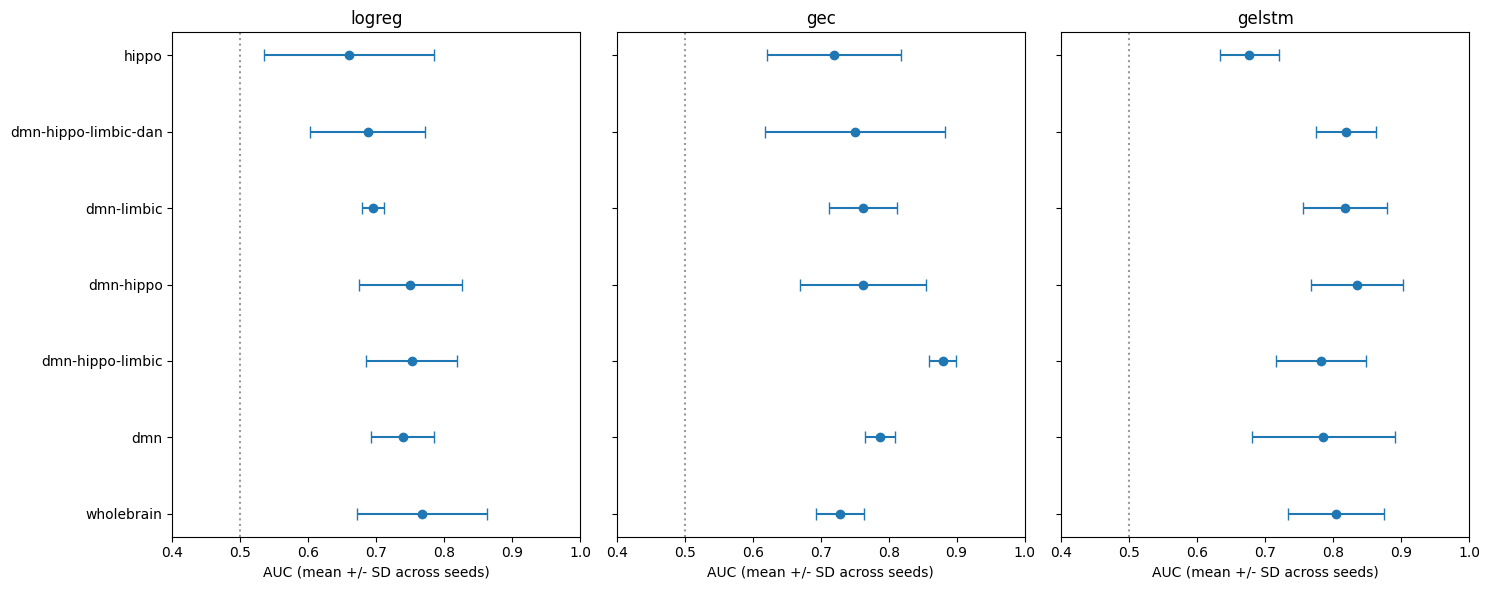

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 6), sharey=True)
if len(MODELS) == 1:
    axes = [axes]
for ax, model in zip(axes, MODELS):
    sub = per_cell_summary[per_cell_summary["model"] == model].copy()
    sub = sub.set_index("region").reindex(REGIONS)
    y = np.arange(len(REGIONS))
    ax.errorbar(sub["auc_mean"], y, xerr=sub["auc_std"], fmt="o", capsize=4)
    ax.set_yticks(y); ax.set_yticklabels(REGIONS)
    ax.axvline(0.5, color="k", linestyle=":", alpha=0.4)
    ax.set_title(model); ax.set_xlabel("AUC (mean +/- SD across seeds)")
    ax.set_xlim(0.4, 1.0)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "forest_auc.png", dpi=150)
plt.show()

## Heatmap - region x model AUC (supplementary)

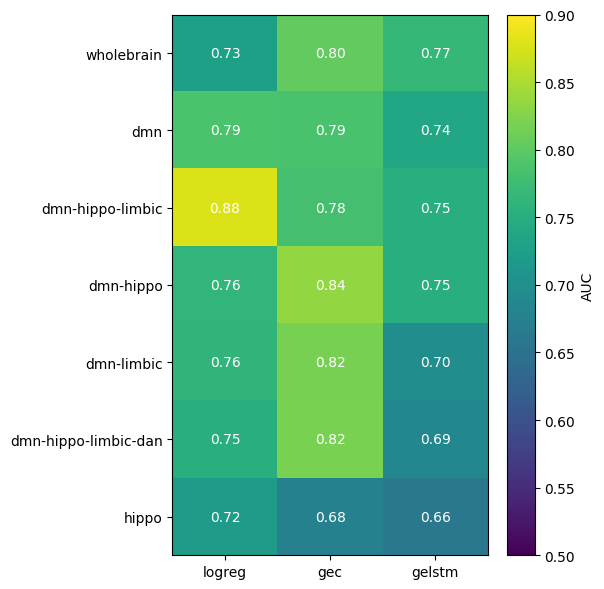

In [10]:
pivot = per_cell_summary.pivot(index="region", columns="model", values="auc_mean").reindex(REGIONS)
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(pivot.values, cmap="viridis", vmin=0.5, vmax=0.9, aspect="auto")
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS)
ax.set_yticks(range(len(REGIONS))); ax.set_yticklabels(REGIONS)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", color="white")
fig.colorbar(im, ax=ax, label="AUC")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "heatmap_auc.png", dpi=150)
plt.show()

## Summary

- `_results/per_cell_summary.csv` - mean +/- SD AUC and F1 per (model, region) across seeds.
- `_results/contrast_table.csv` - 7 pre-registered contrasts x {model}, with raw + Holm-adjusted p, 95% CI for delta-AUC.
- `_results/forest_auc.png`, `_results/heatmap_auc.png` - figures.

Switch `USE_MOCK = False` once real predictions exist under `CLASSIFIER/outputs/<model>-<region>-seed<S>/`.